[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/miguepoloc/toma-decisiones-mcda/blob/main/00_priorizacion_criterios.ipynb)

# Herramienta de priorización de criterios
**Toma de Decisiones Multicriterio · Universidad del Magdalena · Sesión 1**

Versión en Python de la herramienta de priorización de criterios usada en clase (hoja de cálculo equivalente), misma lógica (votación en grupo, escala 1-5, ponderación = promedio), útil si vas a seguir trabajando tu problema en el taller comparativo de la Sesión 4 (`pymcdm`/`pyDecision`).

**Cómo se usa:**
1. Corre la sección "Ejemplo resuelto" para ver cómo funciona: el proceso completo (lluvia de ideas → tamizaje → panel de evidencia → selección final) aplicado a un caso real, elegir la tecnología de comunicación IoT/WSN para una red de sensores agrícolas en Palmor (Sierra Nevada de Santa Marta).
2. Baja hasta "Tu problema" y reemplaza los criterios y las calificaciones por los tuyos.
3. El corte (qué criterios pasan) no lo calcula el notebook por ti, decídelo tú y documenta por qué.

Para el mismo proceso en Excel, con las mismas 5 hojas ("Ejemplo 1. Lluvia de ideas" a "Ejemplo 5. Resultado final"), replicado aquí en Python.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Ejemplo resuelto: elegir tecnología IoT/WSN para una red de sensores agrícolas (Palmor, Sierra Nevada de Santa Marta)

Objetivo: elegir, entre 4 tecnologías de comunicación candidatas (Sigfox, LoRaWAN, celular NB-IoT/2G-3G, Zigbee), cuál usar para una red de sensores de monitoreo agrícola en una zona rural con conectividad limitada. Antes de comparar las alternativas (eso es la Sesión 4), hay que decidir **qué criterios** usar para compararlas — este notebook resuelve esa primera parte.

Mismo proceso de 4 pasos que enseña el curso (y que usa el ejemplo cacaotero del Excel de esta misma carpeta): **1) lluvia de ideas → 2) tamizaje/independencia → 3) panel de evidencia (5 preguntas verificables, 1-5, promedio) → 4) selección final con corte razonado**. El panel de evidencia *no* es una encuesta a expertos simulados — un intento anterior con "expertos" inventados dio un resultado distinto cada vez que se reformulaban los perfiles, evidencia de que ese mecanismo no era confiable. Cada pregunta se responde contra una fuente real (datasheet, 3GPP, IEEE 802.15.4, LoRa Alliance, MinTIC, CRC, prensa especializada), ver la revisión de literatura y prensa especializada citada en el curso para las fuentes completas.

### 1. Lluvia de ideas: 10 criterios candidatos

In [2]:
lluvia_de_ideas = [
    "Alcance de comunicación (rango en km/m por salto)",
    "Consumo energético / autonomía de batería del nodo",
    "Costo por nodo (módulo + despliegue)",
    "Tasa de datos (throughput)",
    "Latencia de transmisión",
    "Escalabilidad (nº de nodos soportables por gateway/celda/red)",
    "Disponibilidad de infraestructura/cobertura comercial en Colombia",
    "Seguridad (cifrado, autenticación)",
    "Facilidad de despliegue (topología, gateway propio vs. red de operador)",
    "Madurez del ecosistema / viabilidad comercial del proveedor a largo plazo",
]
pd.DataFrame({"Candidato": lluvia_de_ideas})

,Candidato
0,Alcance de comunicación (rango en km/m por salto)
1,Consumo energético / autonomía de batería del ...
2,Costo por nodo (módulo + despliegue)
3,Tasa de datos (throughput)
4,Latencia de transmisión
5,Escalabilidad (nº de nodos soportables por gat...
6,Disponibilidad de infraestructura/cobertura co...
7,"Seguridad (cifrado, autenticación)"
8,"Facilidad de despliegue (topología, gateway pr..."
9,Madurez del ecosistema / viabilidad comercial ...


### 2. Tamizaje y verificación de independencia

Se descartan 3 candidatos antes de llegar al panel de evidencia:

- **Facilidad de despliegue** se funde con **Infraestructura en Colombia**: en este contexto rural, "qué tan fácil es desplegar" está dominado casi enteramente por "¿ya existe una red comercial ahí, o hay que montar infraestructura propia?", la misma pregunta para las 4 alternativas.
- **Latencia** se descarta: para sensores ambientales que muestrean cada varios minutos u horas (no video, no control en tiempo real), la latencia de segundos-a-minutos de cualquier LPWAN es irrelevante para este caso de uso.
- **Seguridad** se descarta: las 4 tecnologías ofrecen cifrado equivalente a nivel de especificación, sin diferenciación real para este caso.

Quedan **7 candidatos** para el panel de evidencia. Verificación de independencia de los 4 que terminarán siendo finalistas (ver más abajo): alcance es una propiedad física de la modulación/protocolo, consumo energético es una propiedad de hardware, infraestructura en Colombia es un hecho de mercado actual y local, madurez/viabilidad comercial es un riesgo de negocio a futuro y global — ejes genuinamente distintos: de hecho Sigfox queda primero en alcance pero último en madurez, prueba de que no son la misma variable disfrazada.

In [3]:
candidatos_tras_tamizaje = [c for c in lluvia_de_ideas if c not in (
    "Facilidad de despliegue (topología, gateway propio vs. red de operador)",
    "Latencia de transmisión",
    "Seguridad (cifrado, autenticación)",
)]
len(candidatos_tras_tamizaje), candidatos_tras_tamizaje

(7,
 ['Alcance de comunicación (rango en km/m por salto)',
  'Consumo energético / autonomía de batería del nodo',
  'Costo por nodo (módulo + despliegue)',
  'Tasa de datos (throughput)',
  'Escalabilidad (nº de nodos soportables por gateway/celda/red)',
  'Disponibilidad de infraestructura/cobertura comercial en Colombia',
  'Madurez del ecosistema / viabilidad comercial del proveedor a largo plazo'])

### 3. Panel de evidencia: 5 preguntas verificables (escala 1-5, promedio)

Para cada uno de los 7 candidatos que llegan a esta etapa:

- **Q1:** ¿hay especificación técnica oficial o fuente institucional (datasheet, 3GPP, IEEE 802.15.4, LoRa Alliance, MinTIC, CRC, prensa especializada) que documente este dato para las 4 alternativas?
- **Q2:** ¿el dato es cuantitativo/verificable y comparable entre las 4?
- **Q3:** ¿la evidencia es consistente y actual (no contradictoria, no obsoleta)?
- **Q4:** ¿es independiente de los demás candidatos?
- **Q5:** ¿es directamente crítico para el objetivo del caso?

In [4]:
panel_evidencia = {
    "Alcance de comunicación":                        [5, 5, 5, 5, 5],
    "Consumo energético / autonomía":                 [5, 5, 4, 5, 5],
    "Infraestructura/cobertura en Colombia":          [4, 4, 5, 5, 5],
    "Madurez / viabilidad comercial":                 [4, 4, 5, 4, 4],
    "Tasa de datos":                                  [5, 5, 4, 4, 1],
    "Costo por nodo":                                 [3, 2, 3, 4, 3],
    "Escalabilidad":                                  [2, 2, 2, 4, 3],
}

df = pd.DataFrame(panel_evidencia, index=["Q1", "Q2", "Q3", "Q4", "Q5"]).T
df["Ponderación"] = df.mean(axis=1).round(1)
df = df.sort_values("Ponderación", ascending=False)
df

,Q1,Q2,Q3,Q4,Q5,Ponderación
Alcance de comunicación,5,5,5,5,5,5.0
Consumo energético / autonomía,5,5,4,5,5,4.8
Infraestructura/cobertura en Colombia,4,4,5,5,5,4.6
Madurez / viabilidad comercial,4,4,5,4,4,4.2
Tasa de datos,5,5,4,4,1,3.8
Costo por nodo,3,2,3,4,3,3.0
Escalabilidad,2,2,2,4,3,2.6


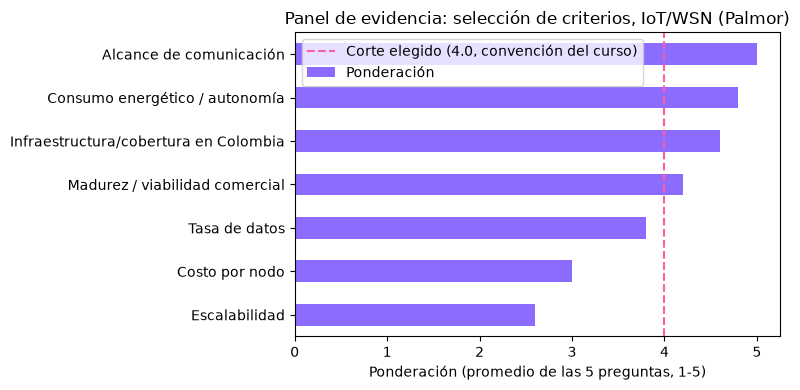

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df["Ponderación"].plot(kind="barh", ax=ax, color="#8B6CFF")
ax.axvline(4.0, color="#FF5DA2", linestyle="--", label="Corte elegido (4.0, convención del curso)")
ax.invert_yaxis()
ax.set_xlabel("Ponderación (promedio de las 5 preguntas, 1-5)")
ax.set_title("Panel de evidencia: selección de criterios, IoT/WSN (Palmor)")
ax.legend()
plt.tight_layout()
plt.show()

### 4. Selección final: 4 criterios, con corte razonado

**Corte elegido: ≥ 4.0** — brecha real frente al siguiente candidato (Tasa de datos, 3.8), misma convención práctica del curso que usa el ejemplo cacaotero del Excel (no es un estándar de la literatura, se documenta el porqué).

**Finalistas (ponderación ≥ 4.0):**

1. **Alcance de comunicación** (5.0) — rango documentado difiere en 2-3 órdenes de magnitud (10 m Zigbee/salto vs. 50 km Sigfox), consistente en las 5 preguntas.
2. **Consumo energético / autonomía** (4.8) — SIM800/900, LoRaWAN, Sigfox bien documentados; solo Zigbee con algo de dispersión entre fuentes.
3. **Infraestructura/cobertura en Colombia** (4.6) — evidencia real y muy dispar entre las 4, y es la premisa misma del caso.
4. **Madurez / viabilidad comercial** (4.2) — evidencia de industria consistente entre fuentes: insolvencia de Sigfox, apagado de 2G en Colombia.

**Candidato en el límite (no incluido, documentado):**

- **Tasa de datos** (3.8) — justo bajo el corte: dato técnico claro pero no crítico, hasta la tasa más baja alcanza para el payload de un sensor ambiental.

**Tabla de descarte, con razón documentada de cada uno:**

| Criterio | Etapa de descarte | Razón |
|---|---|---|
| Costo por nodo (3.0) | Panel de evidencia | Precios de mercado se solapan mucho entre fabricantes, costo total de conectividad en Colombia no documentado públicamente |
| Escalabilidad (2.6) | Panel de evidencia | Sin cifras normalizadas comparables entre paradigmas celular/mesh/propietario |
| Facilidad de despliegue | Tamizaje | Se funde con infraestructura en Colombia |
| Latencia | Tamizaje | Irrelevante para sensores que muestrean cada minutos/horas |
| Seguridad | Tamizaje | Las 4 tecnologías ofrecen cifrado equivalente a nivel de especificación |

**Verificación:** estos 4 finalistas y sus ponderaciones (5.0, 4.8, 4.6, 4.2) coinciden exactamente con los ya verificados en la Sesión 1 (Panorama) del curso.

---
## Tu problema

Reemplaza los criterios candidatos y las calificaciones de abajo por los de tu propio problema de tesis (5 a 15 criterios, tantos evaluadores como consigas, puedes empezar solo con tu propia calificación).

In [6]:
mis_calificaciones = {
    "Criterio candidato 1": [3],
    "Criterio candidato 2": [4],
    "Criterio candidato 3": [5],
}

mi_df = pd.DataFrame(mis_calificaciones).T
mi_df.columns = [f"Evaluador {i+1}" for i in range(mi_df.shape[1])]
mi_df["Ponderación"] = mi_df.mean(axis=1).round(1)
mi_df = mi_df.sort_values("Ponderación", ascending=False)
mi_df

,Evaluador 1,Ponderación
Criterio candidato 3,5,5.0
Criterio candidato 2,4,4.0
Criterio candidato 1,3,3.0
